<a href="https://colab.research.google.com/github/SamiHammouda06/Attaques-Adversariales-sur-Mod-les-ML-AI/blob/main/Projet6.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 29ms/step - accuracy: 0.9065 - loss: 0.3118
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9835 - loss: 0.0528
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 54s 29ms/step - accuracy: 0.9894 - loss: 0.0327
✅ TRAIN      : 14000 images
✅ VALIDATION : 4000 images
✅ TEST       : 2000 images

--- Entraînement du détecteur binaire ---
Epoch 1/5


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


438/438 ━━━━━━━━━━━━━━━━━━━━ 17s 35ms/step - accuracy: 0.9673 - loss: 0.0967 - val_accuracy: 1.0000 - val_loss: 2.6800e-05
Epoch 2/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 1.0000 - loss: 1.8529e-05 - val_accuracy: 1.0000 - val_loss: 6.9444e-06
Epoch 3/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - accuracy: 1.0000 - loss: 5.6838e-06 - val_accuracy: 1.0000 - val_loss: 2.8903e-06
Epoch 4/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 33ms/step - accuracy: 1.0000 - loss: 2.4787e-06 - val_accuracy: 1.0000 - val_loss: 1.5542e-06
Epoch 5/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - accuracy: 1.0000 - loss: 1.5655e-06 - val_accuracy: 1.0000 - val_loss: 9.4876e-07

Images clean pour entraînement classification : 7000
Images clean pour validation classification : 2000

--- Entraînement du classificateur de chiffres ---
Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 8s 29ms/step - accuracy: 0.6812 - loss: 1.0244 - val_accuracy: 0.9500 - val_loss: 0.1617
Epoch 2/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 10s 2

/tmp/ipython-input-947772112.py:262: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-947772112.py:262: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipython-input-947772112.py:262: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128994 (\N{LARGE GREEN CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128992 (\N{LARGE ORANGE CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128308 (\N{LARGE RED CIRCLE}) missing from font(s) DejaVu Sans.
  fig.canvas.print

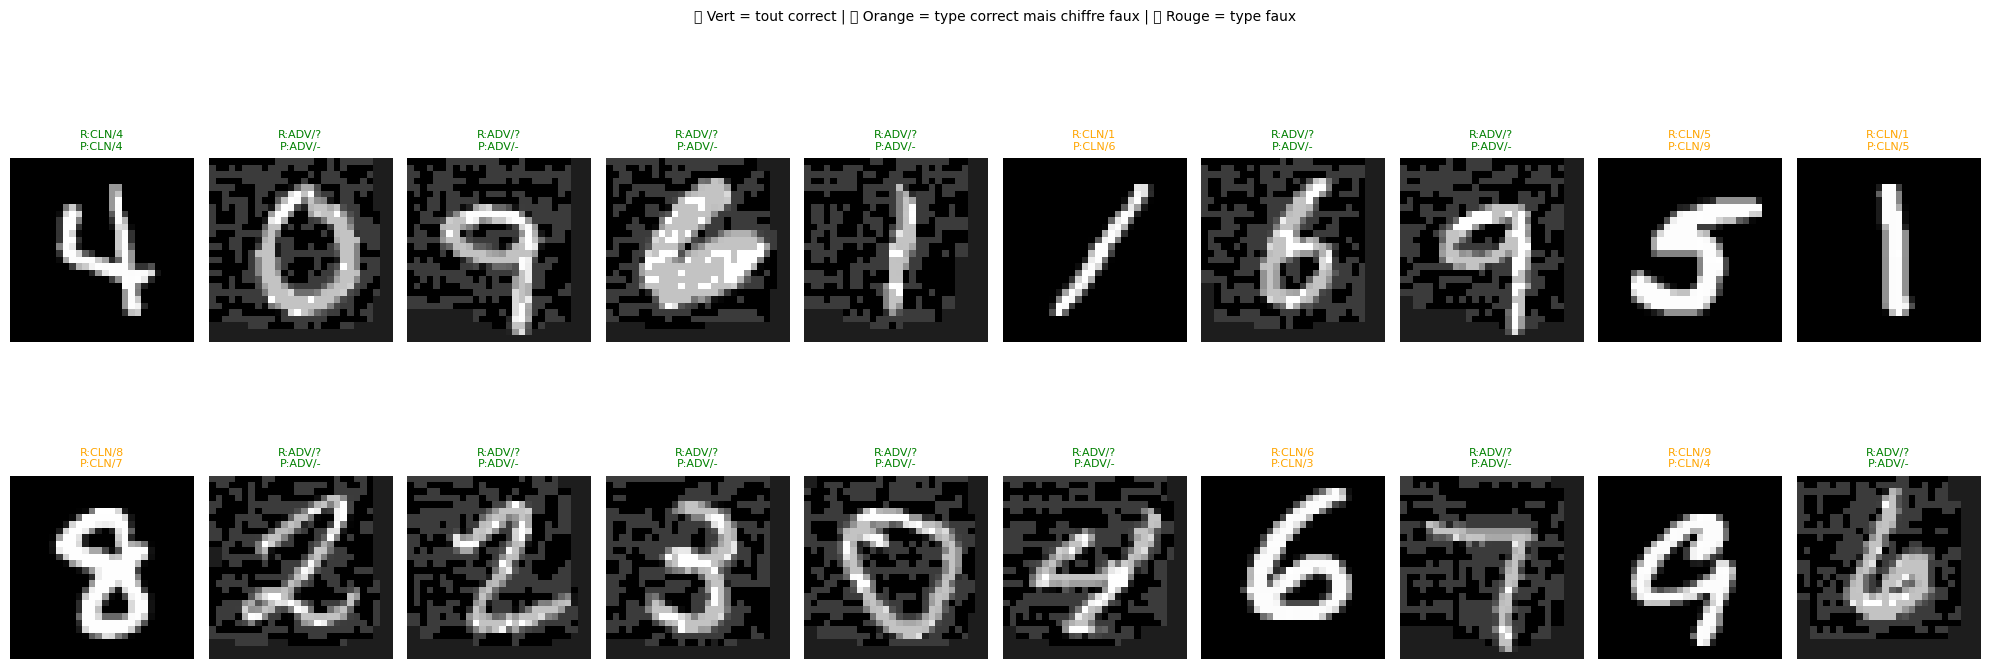

In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
import matplotlib.pyplot as plt


# 1. CHARGEMENT ET NORMALISATION DES DONNÉES MNIST
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test  = x_test  / 255.0

x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]

# 2. MODÈLE VICTIME (CNN classique MNIST)
victim_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

victim_model.compile(optimizer='adam',
                     loss='sparse_categorical_crossentropy',
                     metrics=['accuracy'])

victim_model.fit(x_train, y_train, epochs=3)

# 3. GÉNÉRATION DES IMAGES ADVERSARIALES (FGSM)
loss_object = tf.keras.losses.SparseCategoricalCrossentropy()

def create_adversarial_pattern(image, label):
    image = tf.convert_to_tensor(image)
    label = tf.convert_to_tensor(label)
    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = victim_model(image)
        loss = loss_object(label, prediction)
    gradient = tape.gradient(loss, image)
    signed_grad = tf.sign(gradient)
    return signed_grad

epsilon = 0.15

adv_images = []
for i in range(10000):
    img = x_test[i:i+1]
    lbl = y_test[i:i+1]
    perturbation = create_adversarial_pattern(img, lbl)
    adv_img = img + epsilon * perturbation
    adv_images.append(adv_img.numpy())

adv_images = np.vstack(adv_images)


# 4. CONSTRUCTION DU DATASET POUR LE DÉTECTEUR BINAIRE
#    - 10 000 images clean  (label = 0)
#    - 10 000 images FGSM   (label = 1)
#    Total = 20 000 images

clean_images = x_test[:10000]
clean_labels = y_test[:10000]

X_detector = np.concatenate([clean_images, adv_images])
y_detector_binary = np.concatenate([
    np.zeros(10000),
    np.ones(10000)
])


y_detector_digits = np.concatenate([
    clean_labels,
    np.full(10000, -1)
])

# Mélange aléatoire
X_detector, y_detector_binary, y_detector_digits = shuffle(
    X_detector, y_detector_binary, y_detector_digits, random_state=42
)

# 5. SPLIT 70% TRAIN / 20% VALIDATION / 10% TEST


# --- Étape 1 : Isoler le TEST (10%) ---
X_temp, X_test_det, y_temp_bin, y_test_bin, y_temp_digits, y_test_digits = train_test_split(
    X_detector, y_detector_binary, y_detector_digits,
    test_size=0.10,
    random_state=42,
    stratify=y_detector_binary
)

# --- Étape 2 : Séparer TRAIN (70%) et VALIDATION (20%) ---
X_train_det, X_val_det, y_train_bin, y_val_bin, y_train_digits, y_val_digits = train_test_split(
    X_temp, y_temp_bin, y_temp_digits,
    test_size=0.2222,
    random_state=42,
    stratify=y_temp_bin
)

print(f" TRAIN      : {len(X_train_det)} images")
print(f" VALIDATION : {len(X_val_det)} images")
print(f" TEST       : {len(X_test_det)} images")


# 6. MODÈLE DÉTECTEUR BINAIRE (clean vs adversarial)
detector_model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

detector_model.compile(optimizer='adam',
                       loss='binary_crossentropy',
                       metrics=['accuracy'])

# 7. ENTRAÎNEMENT DU DÉTECTEUR
print("\n--- Entraînement du détecteur binaire ---")
detector_model.fit(
    X_train_det, y_train_bin,
    epochs=5,
    validation_data=(X_val_det, y_val_bin)
)

# 8. MODÈLE DE CLASSIFICATION DES CHIFFRES

# Filtrer uniquement les images clean pour l'entraînement
clean_train_mask = (y_train_bin == 0)
X_train_clean = X_train_det[clean_train_mask]
y_train_clean = y_train_digits[clean_train_mask]

clean_val_mask = (y_val_bin == 0)
X_val_clean = X_val_det[clean_val_mask]
y_val_clean = y_val_digits[clean_val_mask]

print(f"\nImages clean pour entraînement classification : {len(X_train_clean)}")
print(f"Images clean pour validation classification : {len(X_val_clean)}")

# Modèle de classification des chiffres (identique au modèle victime)
digit_classifier = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

digit_classifier.compile(optimizer='adam',
                         loss='sparse_categorical_crossentropy',
                         metrics=['accuracy'])

print("\n--- Entraînement du classificateur de chiffres ---")
digit_classifier.fit(
    X_train_clean, y_train_clean,
    epochs=5,
    validation_data=(X_val_clean, y_val_clean)
)

# 9. ÉVALUATION DU SYSTÈME COMPLET SUR LE TEST
print("\n========== ÉVALUATION SUR LE TEST SET ==========")

# Étape 1: Détection binaire
y_pred_bin_prob = detector_model.predict(X_test_det)
y_pred_bin = (y_pred_bin_prob > 0.5).astype(int).flatten()

print("\n--- Performance du détecteur binaire ---")
cm_bin = confusion_matrix(y_test_bin, y_pred_bin)
print("Matrice de confusion (0=Clean, 1=Adversarial):")
print(cm_bin)
print("\nRapport de classification binaire:")
print(classification_report(y_test_bin, y_pred_bin, target_names=["Clean", "Adversarial"]))

# Étape 2: Classification des chiffres (uniquement sur les images prédites comme clean)
clean_pred_mask = (y_pred_bin == 0)
X_test_pred_clean = X_test_det[clean_pred_mask]
y_test_pred_clean_true = y_test_digits[clean_pred_mask]

if len(X_test_pred_clean) > 0:
    # Prédiction des chiffres
    y_pred_digits_prob = digit_classifier.predict(X_test_pred_clean)
    y_pred_digits = np.argmax(y_pred_digits_prob, axis=1)

    print(f"\n--- Classification des chiffres sur {len(X_test_pred_clean)} images prédites comme clean ---")

    # Calculer la précision seulement sur les images qui sont réellement clean
    true_clean_mask = (y_test_bin[clean_pred_mask] == 0)
    if np.sum(true_clean_mask) > 0:
        digit_accuracy = np.mean(y_pred_digits[true_clean_mask] == y_test_pred_clean_true[true_clean_mask])
        print(f"Précision classification chiffres (sur vraies images clean): {digit_accuracy:.4f}")

    # Matrice de confusion pour les chiffres
    cm_digits = confusion_matrix(y_test_pred_clean_true, y_pred_digits, labels=range(10))
    print("\nMatrice de confusion pour les chiffres:")
    print(cm_digits)
else:
    print("\nAucune image prédite comme clean dans le test set")


# 10. VISUALISATION DES RÉSULTATS
plt.figure(figsize=(20, 8))
for i in range(20):
    plt.subplot(2, 10, i+1)
    plt.imshow(X_test_det[i].reshape(28, 28), cmap='gray')

    # Statut réel
    reel_type = "ADV" if y_test_bin[i] == 1 else "CLN"
    reel_digit = int(y_test_digits[i]) if y_test_digits[i] != -1 else "?"

    # Prédiction
    pred_type = "ADV" if y_pred_bin[i] == 1 else "CLN"
    if pred_type == "CLN" and y_pred_bin[i] == 0 and y_test_bin[i] == 0:
        # Si prédit clean et réellement clean, on prédit aussi le chiffre
        if hasattr(y_pred_digits, '__len__') and len(y_pred_digits) > i:
            pred_digit = y_pred_digits[i] if i < len(y_pred_digits) else "?"
        else:
            pred_digit = "?"
    else:
        pred_digit = "-"

    # Couleur: vert si tout correct, rouge si erreur
    if y_test_bin[i] == y_pred_bin[i]:
        if y_test_bin[i] == 0:  # Si clean
            couleur = "green" if (hasattr(y_pred_digits, '__len__') and i < len(y_pred_digits) and y_pred_digits[i] == y_test_digits[i]) else "orange"
        else:
            couleur = "green"
    else:
        couleur = "red"

    plt.title(f"R:{reel_type}/{reel_digit}\nP:{pred_type}/{pred_digit}", fontsize=8, color=couleur)
    plt.axis('off')

plt.suptitle(" Vert = tout correct |  Orange = type correct mais chiffre faux |  Rouge = type faux", fontsize=10)
plt.tight_layout()
plt.show()

Epoch 1/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 56s 28ms/step - accuracy: 0.9581 - loss: 0.1358
Epoch 2/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 49s 26ms/step - accuracy: 0.9860 - loss: 0.0450
Epoch 3/3
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 50s 27ms/step - accuracy: 0.9901 - loss: 0.0318
Epoch 1/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 16s 33ms/step - accuracy: 0.9881 - loss: 0.0321 - val_accuracy: 1.0000 - val_loss: 5.0281e-05
Epoch 2/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 32ms/step - accuracy: 1.0000 - loss: 3.3499e-05 - val_accuracy: 1.0000 - val_loss: 1.9432e-05
Epoch 3/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 20s 30ms/step - accuracy: 1.0000 - loss: 1.2532e-05 - val_accuracy: 1.0000 - val_loss: 6.9966e-06
Epoch 4/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 14s 31ms/step - accuracy: 1.0000 - loss: 6.2351e-06 - val_accuracy: 1.0000 - val_loss: 5.1646e-06
Epoch 5/5
438/438 ━━━━━━━━━━━━━━━━━━━━ 13s 30ms/step - accuracy: 1.0000 - loss: 3.6781e-06 - val_accuracy: 1.0000 - val_loss: 2.7558e-06
Epoch 1/5
219/219 ━━━━━━━━━━━━━━━━━━━━ 7s 28ms/step 

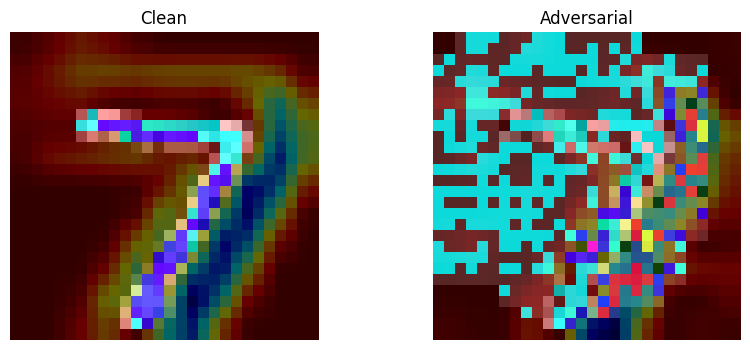

In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import cv2


# 1. DATA
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train / 255.0
x_test  = x_test  / 255.0

x_train = x_train[..., np.newaxis]
x_test  = x_test[..., np.newaxis]

# 2. MODELE VICTIME
victim_model = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu', name="last_conv"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

victim_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

victim_model.fit(x_train, y_train, epochs=3)

# 3. FGSM
loss_object = tf.keras.losses.SparseCategoricalCrossentropy()

def create_adversarial_pattern(image, label):
    image = tf.convert_to_tensor(image)
    label = tf.convert_to_tensor(label)

    with tf.GradientTape() as tape:
        tape.watch(image)
        prediction = victim_model(image)
        loss = loss_object(label, prediction)

    gradient = tape.gradient(loss, image)
    return tf.sign(gradient)

epsilon = 0.15

adv_images = []
for i in range(10000):
    img = x_test[i:i+1]
    lbl = y_test[i:i+1]

    perturbation = create_adversarial_pattern(img, lbl)
    adv_img = img + epsilon * perturbation
    adv_images.append(adv_img.numpy())

adv_images = np.vstack(adv_images)

# 4. DATASET DETECTEUR
clean_images = x_test[:10000]
clean_labels = y_test[:10000]

X_detector = np.concatenate([clean_images, adv_images])

y_detector_binary = np.concatenate([
    np.zeros(10000),
    np.ones(10000)
])

y_detector_digits = np.concatenate([
    clean_labels,
    np.full(10000, -1)
])

X_detector, y_detector_binary, y_detector_digits = shuffle(
    X_detector, y_detector_binary, y_detector_digits, random_state=42
)

# 5. SPLIT
X_temp, X_test_det, y_temp_bin, y_test_bin, y_temp_digits, y_test_digits = train_test_split(
    X_detector, y_detector_binary, y_detector_digits,
    test_size=0.10,
    random_state=42,
    stratify=y_detector_binary
)

X_train_det, X_val_det, y_train_bin, y_val_bin, y_train_digits, y_val_digits = train_test_split(
    X_temp, y_temp_bin, y_temp_digits,
    test_size=0.2222,
    random_state=42,
    stratify=y_temp_bin
)

# 6. DETECTEUR
detector_model = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu', name="last_conv_det"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid')
])

detector_model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

detector_model.fit(
    X_train_det, y_train_bin,
    epochs=5,
    validation_data=(X_val_det, y_val_bin)
)

# 7. CLASSIFICATEUR (CLEAN)
mask = (y_train_bin == 0)
X_train_clean = X_train_det[mask]
y_train_clean = y_train_digits[mask]

mask_val = (y_val_bin == 0)
X_val_clean = X_val_det[mask_val]
y_val_clean = y_val_digits[mask_val]

digit_classifier = models.Sequential([
    layers.Input(shape=(28,28,1)),
    layers.Conv2D(32, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),
    layers.Conv2D(64, (3,3), activation='relu', name="last_conv_cls"),
    layers.MaxPooling2D(2,2),
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

digit_classifier.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

digit_classifier.fit(
    X_train_clean, y_train_clean,
    epochs=5,
    validation_data=(X_val_clean, y_val_clean)
)

# 8. GRAD-CAM (CORRIGE)
victim_model(x_test[:1])

def make_gradcam_heatmap(img_array, model, last_conv_layer_name):

    grad_model = tf.keras.models.Model(
        inputs=model.inputs,
        outputs=[
            model.get_layer(last_conv_layer_name).output,
            model.outputs[0]
        ]
    )

    img_tensor = tf.convert_to_tensor(img_array)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor)

        pred_index = tf.argmax(predictions[0])
        class_channel = predictions[:, pred_index]

    grads = tape.gradient(class_channel, conv_outputs)

    pooled_grads = tf.reduce_mean(grads, axis=(0,1,2))

    conv_outputs = conv_outputs[0]

    heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap = tf.squeeze(heatmap)

    # stabilité
    heatmap = tf.maximum(heatmap, 0)
    heatmap /= (tf.reduce_max(heatmap) + 1e-8)

    return heatmap.numpy()

def display_gradcam(img, heatmap):
    img = img.reshape(28,28)

    heatmap = cv2.resize(heatmap, (28,28))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    superimposed = heatmap * 0.4 + np.stack([img*255]*3, axis=-1)

    plt.imshow(superimposed.astype("uint8"))
    plt.axis('off')

# 9. VISUALISATION
index = 0

img_clean = x_test[index:index+1]
img_adv   = adv_images[index:index+1]

heatmap_clean = make_gradcam_heatmap(img_clean, victim_model, "last_conv")
heatmap_adv   = make_gradcam_heatmap(img_adv, victim_model, "last_conv")

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.title("Clean")
display_gradcam(img_clean[0], heatmap_clean)

plt.subplot(1,2,2)
plt.title("Adversarial")
display_gradcam(img_adv[0], heatmap_adv)

plt.show()

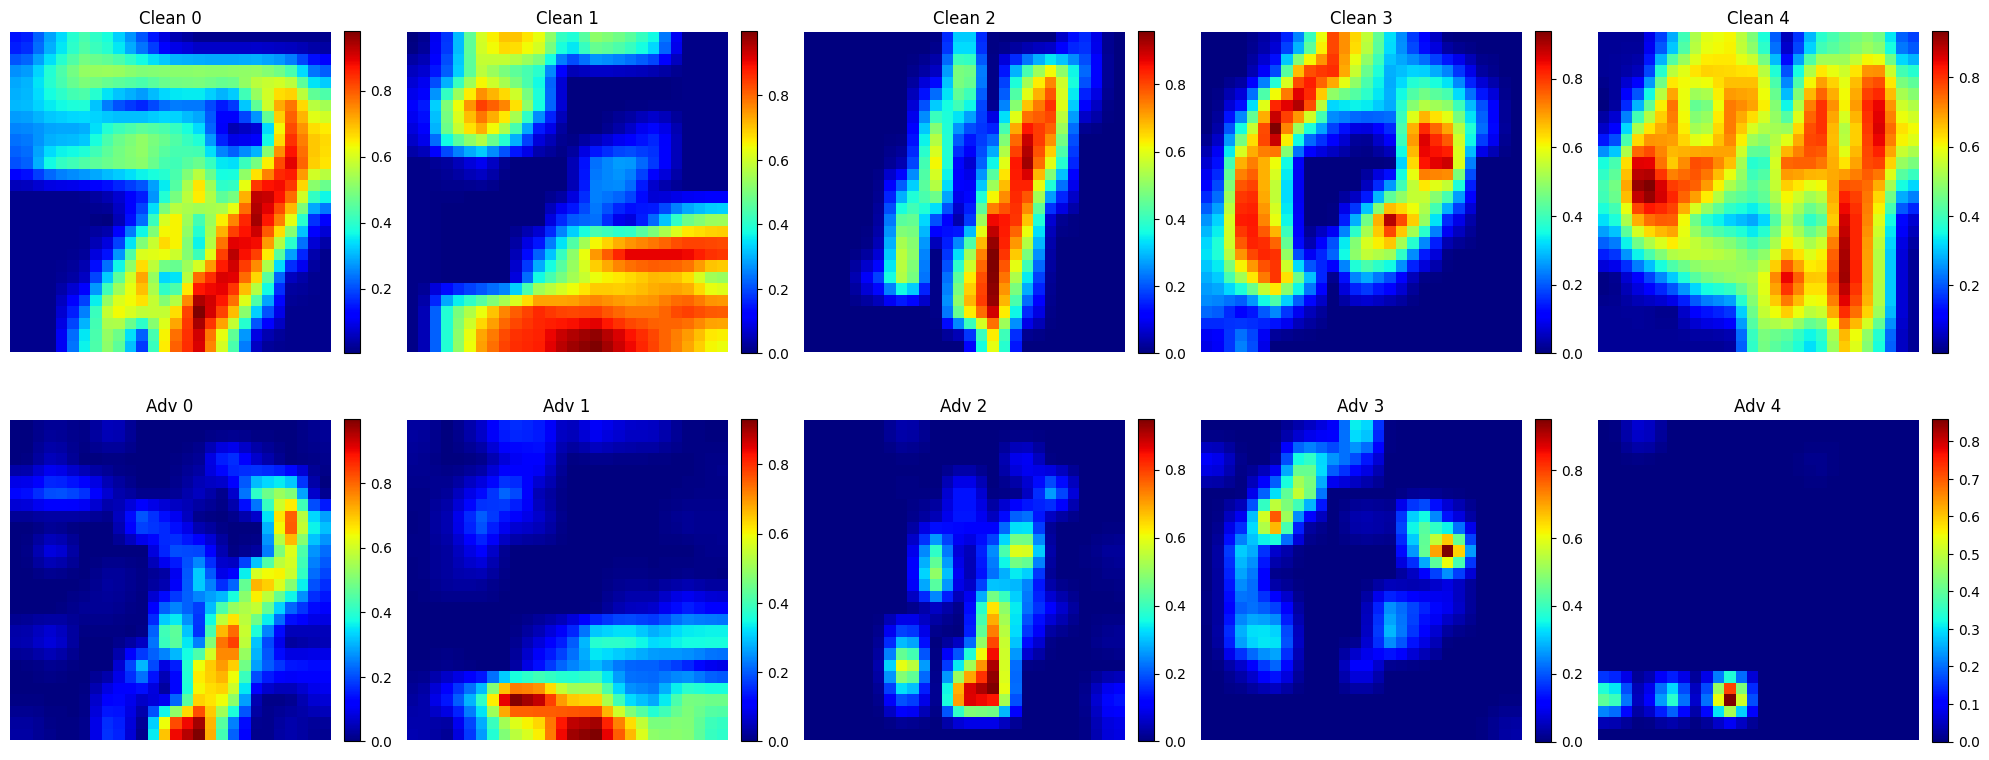

In [ ]:

# 10 IMAGES : 5 CLEAN + 5 ADVERSARIALES

def boost_clean(heatmap, gamma=0.5):
    heatmap = heatmap.copy()
    heatmap = heatmap ** gamma
    heatmap = heatmap / (np.max(heatmap) + 1e-8)
    return heatmap


indices = [0, 1, 2, 3, 4]

clean_imgs = [x_test[i] for i in indices]
adv_imgs   = [adv_images[i] for i in indices]

clean_heatmaps = [
    make_gradcam_heatmap(img[None, ...], victim_model, "last_conv")
    for img in clean_imgs
]

adv_heatmaps = [
    make_gradcam_heatmap(img[None, ...], victim_model, "last_conv")
    for img in adv_imgs
]

# DISPLAY GRID 2x5
plt.figure(figsize=(20, 8))

for i in range(5):

    # ---------------- CLEAN (PLUS CLAIR) ----------------
    plt.subplot(2, 5, i + 1)

    heatmap_c = cv2.resize(
        boost_clean(clean_heatmaps[i], gamma=0.5),
        (28,28)
    )

    im = plt.imshow(heatmap_c, cmap='jet')
    plt.title(f"Clean {i}")
    plt.axis('off')
    plt.colorbar(im, fraction=0.046, pad=0.04)

    # ---------------- ADVERSARIAL (NORMAL) ----------------
    plt.subplot(2, 5, i + 6)

    heatmap_a = cv2.resize(adv_heatmaps[i], (28,28))

    im2 = plt.imshow(heatmap_a, cmap='jet')
    plt.title(f"Adv {i}")
    plt.axis('off')
    plt.colorbar(im2, fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()